## Importamos el Código.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [2]:
insurance = pd.read_csv('insurance.csv')

# Análisis Exploratorio de Datos (EDA) — Medical Cost Personal Dataset

## 1. Descripción del dataset
El dataset utilizado en este proyecto es el Medical Cost Personal Dataset, disponible en Kaggle:

**Fuente:**  
Medical Cost Personal Dataset – Kaggle  
https://www.kaggle.com/datasets/mirichoi0218/insurance

El conjunto contiene 1.338 individuos junto con atributos demográficos, hábitos personales y su coste médico anual.

---

## 2. Variables del dataset
- age: edad del asegurado.  
- sex: sexo (male/female).  
- bmi: índice de masa corporal (IMC).  
- children: número de hijos dependientes.  
- smoker: si la persona fuma (yes/no).  
- region: región de residencia (northeast, northwest, southeast, southwest).  
- charges: coste médico anual (variable objetivo).

---

## 3. Objetivo del EDA 
El objetivo del proyecto es predecir los costes médicos individuales (`charges`) de un individuo a partir de sus características personales, demográficas y de hábitos, planteando el problema como un problema de regresión supervisada.

El EDA se centra en:
- entender la estructura del dataset  
- analizar distribuciones  
- detectar anomalías o patrones  
- relacionar variables con *charges*  
- dejar el dataset listo para modelización  

---

## 4. Comprobación inicial del dataset
A continuación, se revisan:
- primeras filas (`head`)  
- estructura (`info`)  
- valores faltantes  
- duplicados  
- tipos de variables  

### Entedemos el Dataset.

In [3]:
insurance.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df=pd.DataFrame(insurance)

In [5]:
df.shape

(1338, 7)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

### 4.1 Análisis y tratamiento de los valores faltantes

Se revisa la presencia de los valores faltantes con:

In [8]:
df.isna().sum().sort_values()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

El dataset no contiene valores nulos en ninguna columna.
Entonces, no es necesario cambiar los NA con la media, mediana o moda.

### 4.2 Análisis y tratamiento de valores duplicados

Se revisa la presencia de los valores duplicados con:

In [9]:
duplicado = df.duplicated().sum() # Comprobar duplicados
print(duplicado)

df[df.duplicated(keep="first")]

1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


Qutamos los duplicados con el (keep = False).

Se detectó 1 registro duplicado completamente idéntico. Entonces eliminamos para así evitar sesgos y dejar el dataset limpio de duplicados.

### Vamos a renombrar el df tras quitar los duplicados, para así mantener una mayor claridad.

In [10]:
insurance_limpio = df


In [11]:
insurance_limpio.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
insurance_limpio.describe(include='object') # Moda, nº categorias, frequencia de la moda en variables categoricas

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [13]:
insurance_limpio['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [14]:
insurance_limpio['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [15]:
insurance_limpio['sex'].unique()

array(['female', 'male'], dtype=object)

In [16]:
insurance_limpio['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [17]:
insurance_limpio['age'].unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39])

In [18]:
insurance_limpio['age'].max()

np.int64(64)

### LIMPIEZA Y TRANFORMACIÓN DEL DATASET

Cambiamos las variables de smoker y sex por 0 y 1 para facilitar el análisis y redondeamos a 2 decimales

In [19]:
insurance_limpio['sex']=insurance_limpio['sex'].map({'male': 1, 'female': 0})
insurance_limpio['smoker']=insurance_limpio['smoker'].map({'yes': 1, 'no': 0})

In [20]:
insurance_limpio['charges']=insurance_limpio['charges'].round(2)
insurance_limpio['bmi']=insurance_limpio['bmi'].round(2)

In [21]:
insurance_limpio['sex'].unique()

array([0, 1])

In [22]:
insurance_limpio['smoker'].unique()

array([1, 0])

In [23]:
bins = [0, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']

insurance_limpio['age_group'] = pd.cut(insurance['age'], bins=bins, labels=labels)

In [24]:
insurance_limpio['age_group'].unique()

['18-25', '26-35', '46-55', '36-45', '56+']
Categories (5, object): ['18-25' < '26-35' < '36-45' < '46-55' < '56+']

Los rangos de edad se han definido en cinco grupos:  
18–25, 26–35, 36–45, 46–55 y 56+.  
Estos grupos permiten convertir la predicción de edad en un problema de clasificación.

In [25]:
insurance_limpio=insurance_limpio.drop(columns=['age'])

In [26]:
insurance_limpio['age_group'].value_counts().sort_index()

age_group
18-25    306
26-35    268
36-45    264
46-55    284
56+      216
Name: count, dtype: int64

## ANÁLISIS UNIVARIANTE

### VARIABLES CATEGÓRICAS

### SEX

In [27]:
insurance_limpio['sex'].value_counts()

sex
1    676
0    662
Name: count, dtype: int64

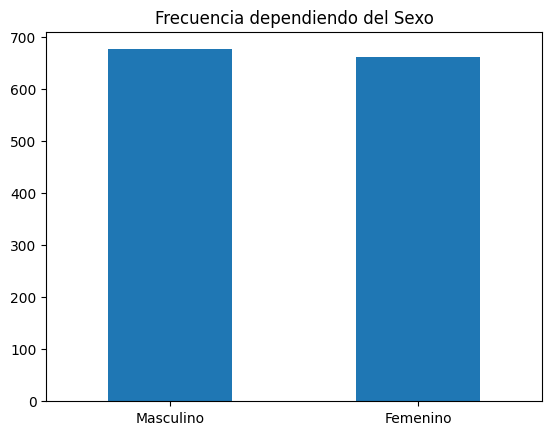

In [28]:
insurance_limpio['sex'].value_counts().plot(kind='bar')

plt.title('Frecuencia dependiendo del Sexo')
plt.xlabel('')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['Masculino', 'Femenino'], rotation=0)
plt.show()

In [29]:
print((insurance_limpio['sex'].value_counts(normalize=True)*100).round(2).astype(str) + '%')

sex
1    50.52%
0    49.48%
Name: proportion, dtype: object


### AGE

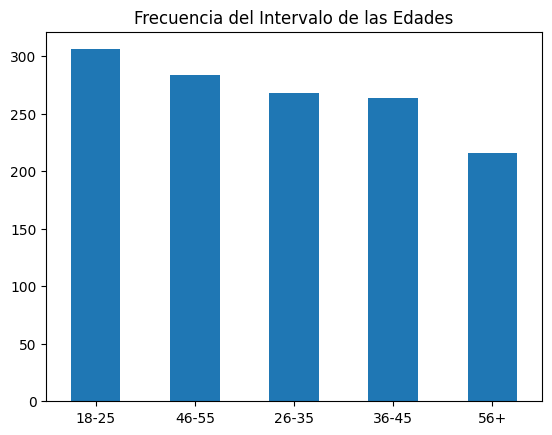

In [30]:
insurance_limpio['age_group'].value_counts().plot(kind='bar')
plt.title('Frecuencia del Intervalo de las Edades') 

plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0)
plt.show()


In [31]:
print((insurance_limpio['age_group'].value_counts(normalize=True)*100).round(2).astype(str) + '%')

age_group
18-25    22.87%
46-55    21.23%
26-35    20.03%
36-45    19.73%
56+      16.14%
Name: proportion, dtype: object


### SMOKER

In [32]:
insurance_limpio['smoker'].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

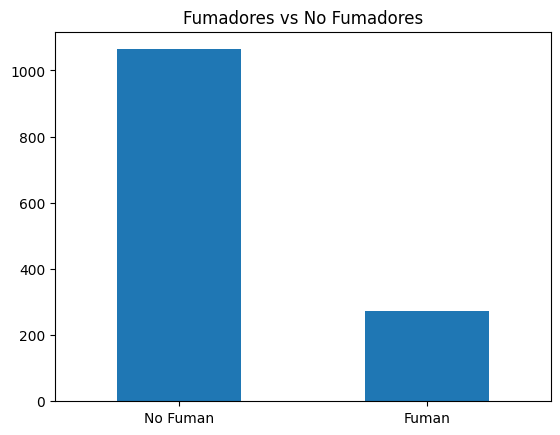

In [33]:
insurance_limpio['smoker'].value_counts().plot(kind='bar')
plt.title('Fumadores vs No Fumadores') 

plt.xlabel('')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No Fuman', 'Fuman'], rotation=0)
plt.show()

In [34]:
print((insurance_limpio['smoker'].value_counts(normalize=True)*100).round(2).astype(str) + '%')

smoker
0    79.52%
1    20.48%
Name: proportion, dtype: object


### REGION

In [35]:
insurance_limpio['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

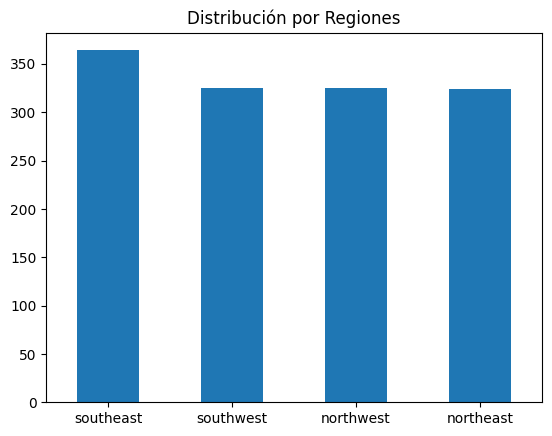

In [36]:
insurance_limpio['region'].value_counts().plot(kind='bar')
plt.title('Distribución por Regiones') 

plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0)
plt.show()

In [37]:
print((insurance_limpio['region'].value_counts(normalize=True)*100).round(2).astype(str) + '%')

region
southeast     27.2%
southwest    24.29%
northwest    24.29%
northeast    24.22%
Name: proportion, dtype: object


In [38]:
insurance_limpio.head()

,sex,bmi,children,smoker,region,charges,age_group
0,0,27.90,0,1,southwest,16884.92,18-25
1,1,33.77,1,0,southeast,1725.55,18-25
2,1,33.00,3,0,southeast,4449.46,26-35
3,1,22.70,0,0,northwest,21984.47,26-35
4,1,28.88,0,0,northwest,3866.86,26-35


## VARIABLES NUMÉRICAS

### BMI

In [39]:
insurance_limpio['bmi'].describe()

count    1338.000000
mean       30.663572
std         6.097951
min        15.960000
25%        26.297500
50%        30.400000
75%        34.692500
max        53.130000
Name: bmi, dtype: float64

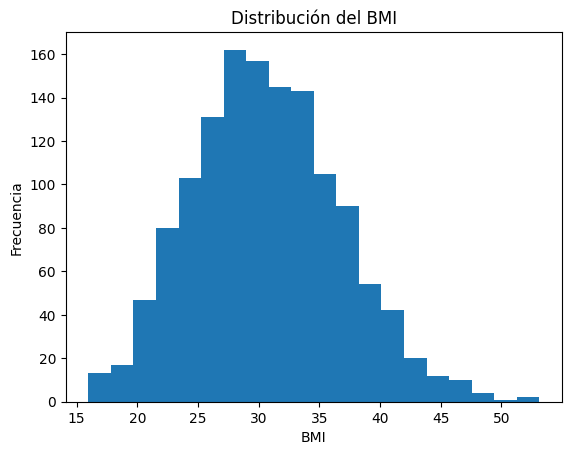

In [40]:
insurance_limpio['bmi'].plot(kind='hist', bins=20)
plt.title('Distribución del BMI')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()

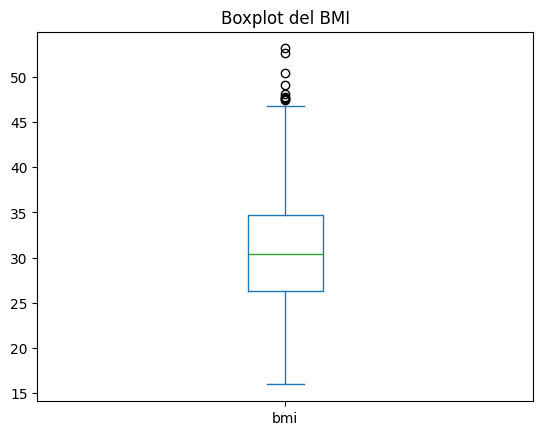

In [41]:
insurance_limpio['bmi'].plot(kind='box')
plt.title('Boxplot del BMI')
plt.show()

La explicación biológica es la siguiente: BMI = peso(kg)/altura(m)^2

### CHILDREN

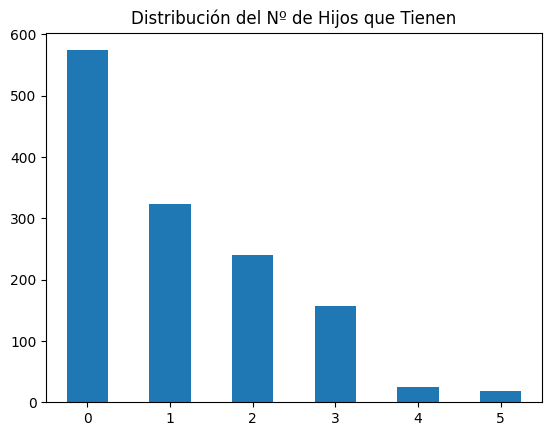

In [42]:
insurance_limpio['children'].value_counts().plot(kind='bar')
plt.title('Distribución del Nº de Hijos que Tienen') 

plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0)
plt.show()

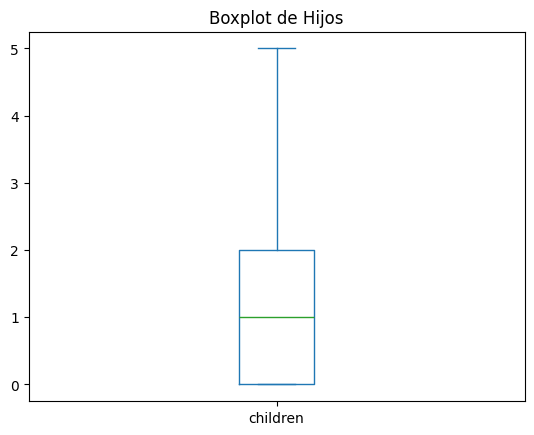

In [43]:
insurance_limpio['children'].plot(kind='box')
plt.title('Boxplot de Hijos')
plt.show()

### CHARGES

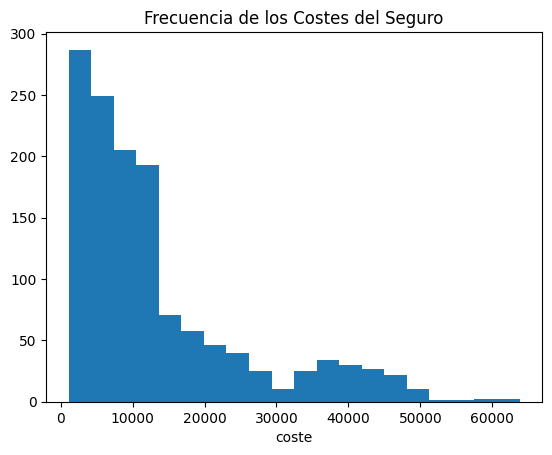

In [44]:
insurance_limpio['charges'].plot(kind='hist', bins=20)
plt.title('Frecuencia de los Costes del Seguro')
plt.xlabel('coste')
plt.ylabel('')
plt.show()

## 5. Conclusiones del análisis univariante

### Age
Distribución uniforme entre los intervalos de edad 18-25 y 56+ años, con ligera concentración en edades medias.

### Sex
Distribución equilibrada entre hombres y mujeres.

### BMI
Distribución ligeramente sesgada hacia la derecha, media ≈ 30.6.  
Valores altos pueden implicar mayor riesgo médico.

### Children
Mayoría de individuos entre 0 y 2 hijos.

### Smoker
Pocos fumadores respecto a no fumadores, pero es una variable clave.

### Region
Distribución bastante homogénea entre las 4 regiones.

### Charges
Distribución muy sesgada: la mayoría pagan menos de 15.000, pero existen valores muy altos.  
Muy probablemente la variable con mayor variabilidad explicada por *smoker*, *age* y *bmi*.

## Análisis Bivariante

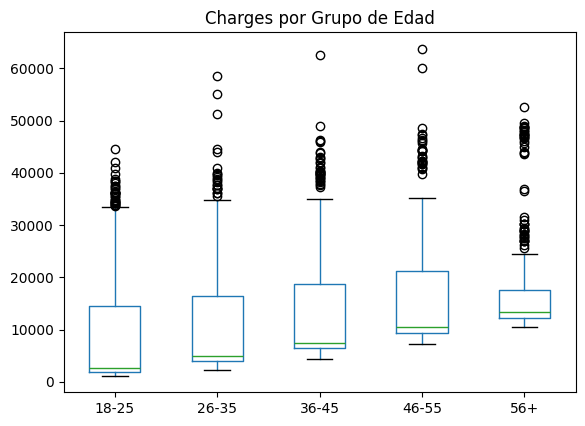

In [45]:
insurance_limpio.boxplot(column='charges', by='age_group')
plt.title("Charges por Grupo de Edad")
plt.suptitle("")   # Quita el subtítulo automático de pandas
plt.xlabel("")
plt.ylabel("")

plt.grid(False)
plt.show()

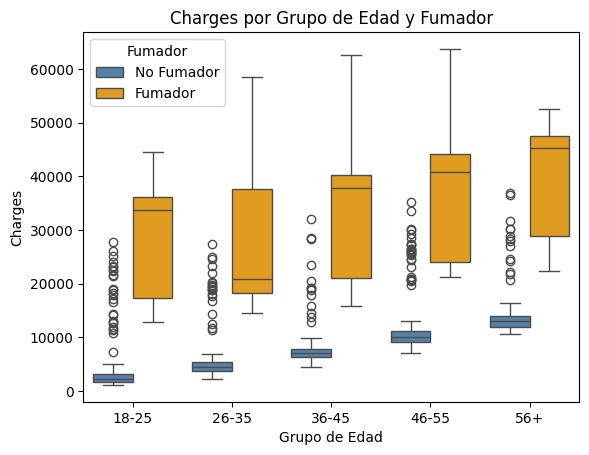

In [46]:
ax = sns.boxplot(data=insurance_limpio, x='age_group', y='charges', hue='smoker', hue_order=[0, 1], palette={0: "steelblue", 1: "orange"})

plt.title("Charges por Grupo de Edad y Fumador")
plt.xlabel("Grupo de Edad")
plt.ylabel("Charges")


handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ["No Fumador", "Fumador"], title="Fumador")

plt.show()

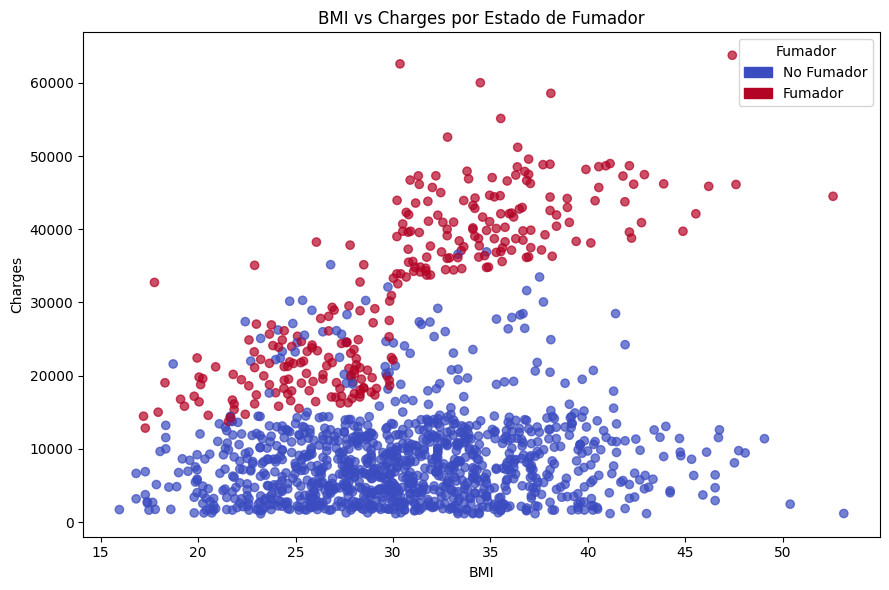

In [47]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(insurance_limpio['bmi'], insurance_limpio['charges'], c=insurance_limpio['smoker'], cmap='coolwarm', alpha=0.7)

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges por Estado de Fumador")

no_fumador = mpatches.Patch(color=plt.cm.coolwarm(0.0), label='No Fumador')
fumador = mpatches.Patch(color=plt.cm.coolwarm(1.0), label='Fumador')

plt.legend(handles=[no_fumador, fumador], title="Fumador")

plt.tight_layout()
plt.show()

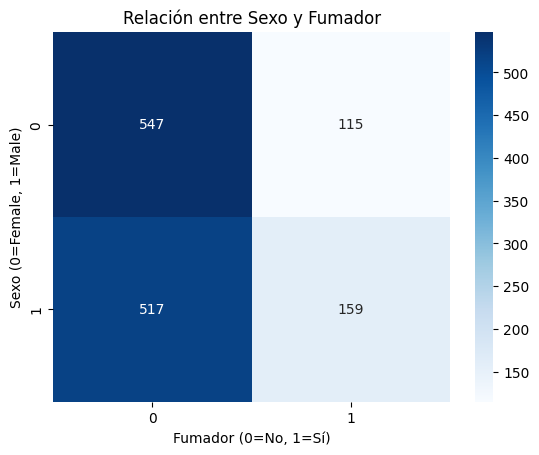

In [48]:
tabla = pd.crosstab(insurance_limpio['sex'], insurance_limpio['smoker'])

sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Relación entre Sexo y Fumador")
plt.xlabel("Fumador (0=No, 1=Sí)")
plt.ylabel("Sexo (0=Female, 1=Male)")
plt.show()

Los hombres fuman un 38% más que las mujeres.

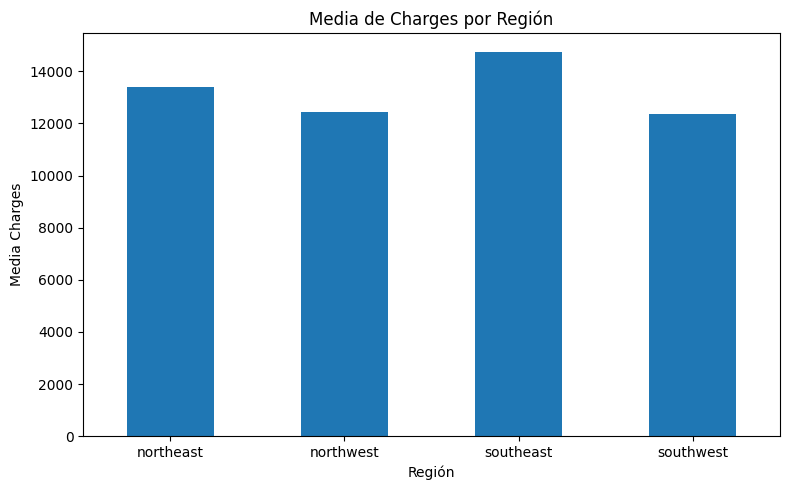

In [49]:
media_charges_region = insurance_limpio.groupby('region')['charges'].mean()

plt.figure(figsize=(8,5))
media_charges_region.plot(kind='bar')
plt.title("Media de Charges por Región")
plt.xlabel("Región")
plt.ylabel("Media Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La media de cargos más alta es en el sureste, mientras que la media en las otras 3 zonas es relativamente parecida.

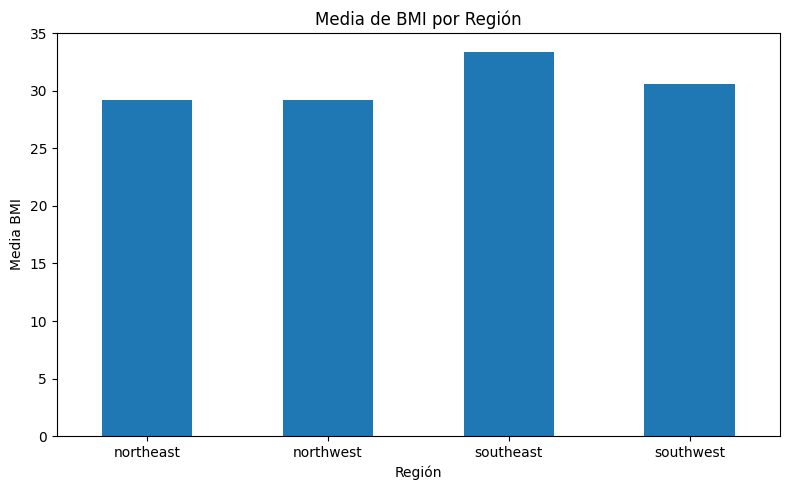

In [50]:
media_bmi_region = insurance_limpio.groupby('region')['bmi'].mean()

plt.figure(figsize=(8,5))
media_bmi_region.plot(kind='bar')
plt.title("Media de BMI por Región")
plt.xlabel("Región")
plt.ylabel("Media BMI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

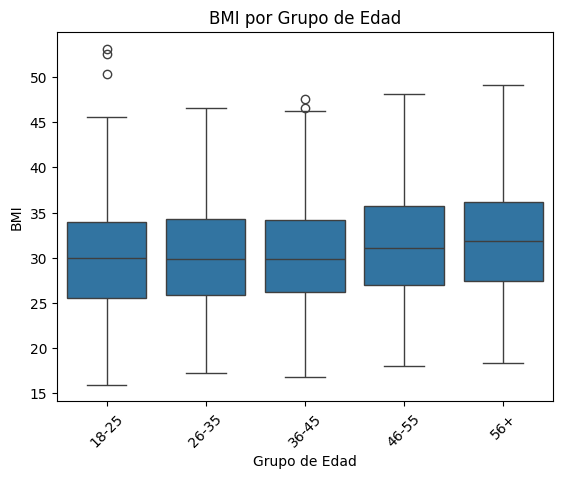

In [51]:
sns.boxplot(data=insurance_limpio, x='age_group', y='bmi')
plt.title("BMI por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("BMI")
plt.xticks(rotation=45)
plt.show()

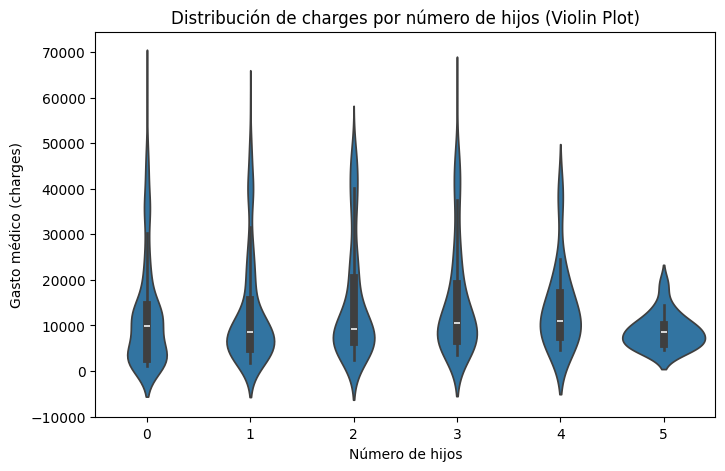

In [52]:
plt.figure(figsize=(8,5))
sns.violinplot(data=insurance_limpio, x='children', y='charges', inner='box')
plt.title('Distribución de charges por número de hijos (Violin Plot)')
plt.xlabel('Número de hijos')
plt.ylabel('Gasto médico (charges)')
plt.show()

C:\Users\pablo\AppData\Local\Temp\ipykernel_6428\3730623395.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


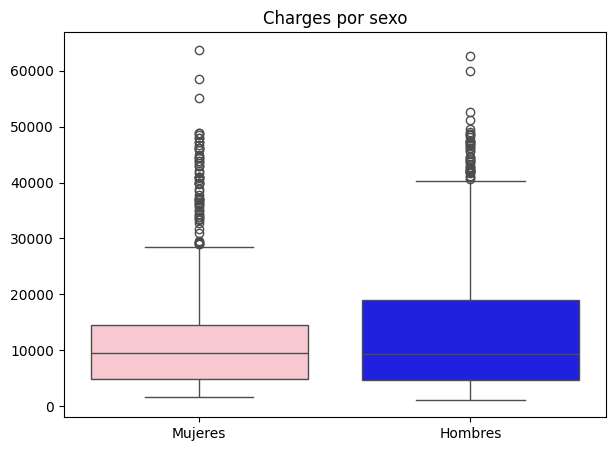

In [53]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=insurance_limpio, 
    x='sex', 
    y='charges',
    palette=['pink', 'blue']   # 0 = Mujeres (rosa), 1 = Hombres (azul)
)
plt.xticks(ticks=[0, 1], labels=['Mujeres', 'Hombres'])
plt.title('Charges por sexo')
plt.xlabel('')
plt.ylabel('')
plt.show()

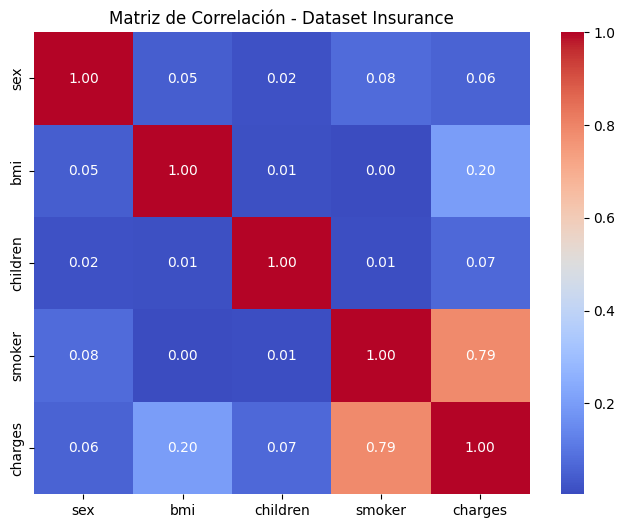

In [54]:
numericas = insurance_limpio.select_dtypes(include='number')

corr_matrix = numericas.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Dataset Insurance")
plt.show()

## 6. Conclusiones del análisis bivariante

Tras analizar la relación entre variables y el target (charges), se observa:

### Smoker vs Charges
Es la relación más fuerte.  
Los fumadores presentan costes médicos dramáticamente más altos.

### BMI vs Charges
Relación creciente: IMC alto hay un mayor coste.  
Especialmente crítico cuando coincide con ser fumador.

### Age vs Charges
Relación positiva clara: a mayor edad, hay mayores charges.

### Region vs Charges
Existen diferencias moderadas, siendo el southeast el de mayor media.  
No parece una variable tan explicativa como smoker, age o BMI.

### Sex vs Charges
Diferencias ligeras, aunque no muy significativas.

---

Estas conclusiones ayudarán a seleccionar las variables más relevantes en el futuro modelo de regresión.

---
## 7. Conclusión general del EDA

El análisis exploratorio permite concluir que:

- Las variables con mayor impacto potencial en `charges` son `smoker`, `age` y `bmi`.  
- No existen valores faltantes en el dataset.  
- Los valores atípicos se mantienen, ya que son representativos de casos reales.  
- El dataset muestra patrones sólidos que permitirán construir modelos de regresión supervisada con buena capacidad predictiva.  
- El dataset se encuentra limpio y preparado para pasar a la siguiente fase de preprocesado avanzado y modelización.

Este EDA proporciona una base sólida para el desarrollo del resto del proyecto de Aprendizaje Automático.